In [21]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter

plt.rcParams.update({
    "font.family":        "serif",
    "font.serif":         ["Times New Roman", "DejaVu Serif"],
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.labelsize":     11,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "legend.fontsize":    9,
    "figure.dpi":         150,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.alpha":         0.3,
    "grid.linewidth":     0.5,
    "axes.linewidth":     0.8,
})
 
# Paleta daltônica e publicável (máx. contraste em P&B também)
PALETTE = {
    "BTC-USD": "#e67e22",   # azul escuro  — ativo principal
    "^GSPC":   "#c0392b",   # vermelho      — S&P 500
    "^BVSP":   "#1f4e79",   # verde         — Ibovespa
    "GC=F":    "#f2ff00",   # laranja       — Ouro
    "BRL=X":   "#00b700",   # roxo          — Dólar/BRL
}
 
LABELS = {
    "BTC-USD": "Bitcoin (BTC)",
    "^GSPC":   "S&P 500",
    "^BVSP":   "Ibovespa",
    "GC=F":    "Ouro",
    "BRL=X":   "Dólar/Real",
}
 
TICKERS = list(PALETTE.keys())

In [22]:
TICKERS = {
    "BTC-USD": "Bitcoin (BTC)",
    "^GSPC":   "S&P 500",
    "^BVSP":   "Ibovespa",
    "GC=F":    "Ouro",
    "BRL=X":   "Dólar/Real",
}

def calcular_rv_diaria(series: pd.Series) -> pd.Series:
    """
    Replica exatamente seu cálculo de volatilidade realizada.
    Entrada: série de preços com índice datetime (qualquer frequência).
    Saída: série de RV diária com índice date.
    """
    df = series.to_frame(name="price").dropna()
    df["shifted"]  = df["price"].shift(1)
    df["returns"]  = np.log(df["price"] / df["shifted"])
    df["vol"]      = df["returns"] ** 2
    df = df.groupby(df.index.date)["vol"].sum()
    df = df.dropna().iloc[1:]          # remove primeiro dia (sem retorno)
    return df


# ── Download de preços diários ────────────────────────────────────────────────
raw = yf.download(
    list(TICKERS.keys()),
    start="2018-01-01",
    end="2024-12-31",
    auto_adjust=True,
    progress=False,
)["Close"]

# ── Calcular RV para cada ativo individualmente ───────────────────────────────
rv_dict = {}
for ticker in TICKERS:
    if ticker in raw.columns:
        rv_dict[ticker] = calcular_rv_diaria(raw[ticker])

# Montar DataFrame — índice = date, colunas = tickers
rv_raw = pd.DataFrame(rv_dict)
rv_raw.index = pd.to_datetime(rv_raw.index)
rv_raw.columns = [TICKERS[t] for t in rv_raw.columns]

print("Shape antes do tratamento:", rv_raw.shape)
print("NaNs por ativo:\n", rv_raw.isna().sum())

Shape antes do tratamento: (2555, 5)
NaNs por ativo:
 Bitcoin (BTC)      0
S&P 500          796
Ibovespa         819
Ouro             797
Dólar/Real       731
dtype: int64


In [23]:
rv_intersecao = rv_raw.dropna(how="any")
print("Shape após dropna:", rv_intersecao.shape[0])
rv_intersecao

Shape após dropna: 1689


,Bitcoin (BTC),S&P 500,Ibovespa,Ouro,Dólar/Real
2018-01-03,0.000210,4.068441e-05,1.780379e-06,3.614613e-06,2.623797e-04
2018-01-04,0.000669,1.616476e-05,6.930168e-05,5.896866e-06,4.717831e-05
2018-01-05,0.012309,4.912813e-05,2.890888e-05,4.650069e-07,5.507059e-07
2018-01-08,0.006835,2.758801e-06,1.511395e-05,1.660158e-06,4.050075e-06
2018-01-09,0.001491,1.695421e-06,4.236708e-05,2.752661e-05,1.471287e-05
...,...,...,...,...,...
2024-12-20,0.000007,1.168665e-04,5.645572e-05,1.955101e-04,4.872600e-04
2024-12-23,0.000019,5.271994e-05,1.208613e-04,3.916670e-05,1.213734e-04
2024-12-26,0.001290,1.646258e-07,6.614652e-06,5.112206e-05,1.357601e-06
2024-12-27,0.000295,1.235945e-04,4.494449e-05,6.755626e-05,3.094774e-05


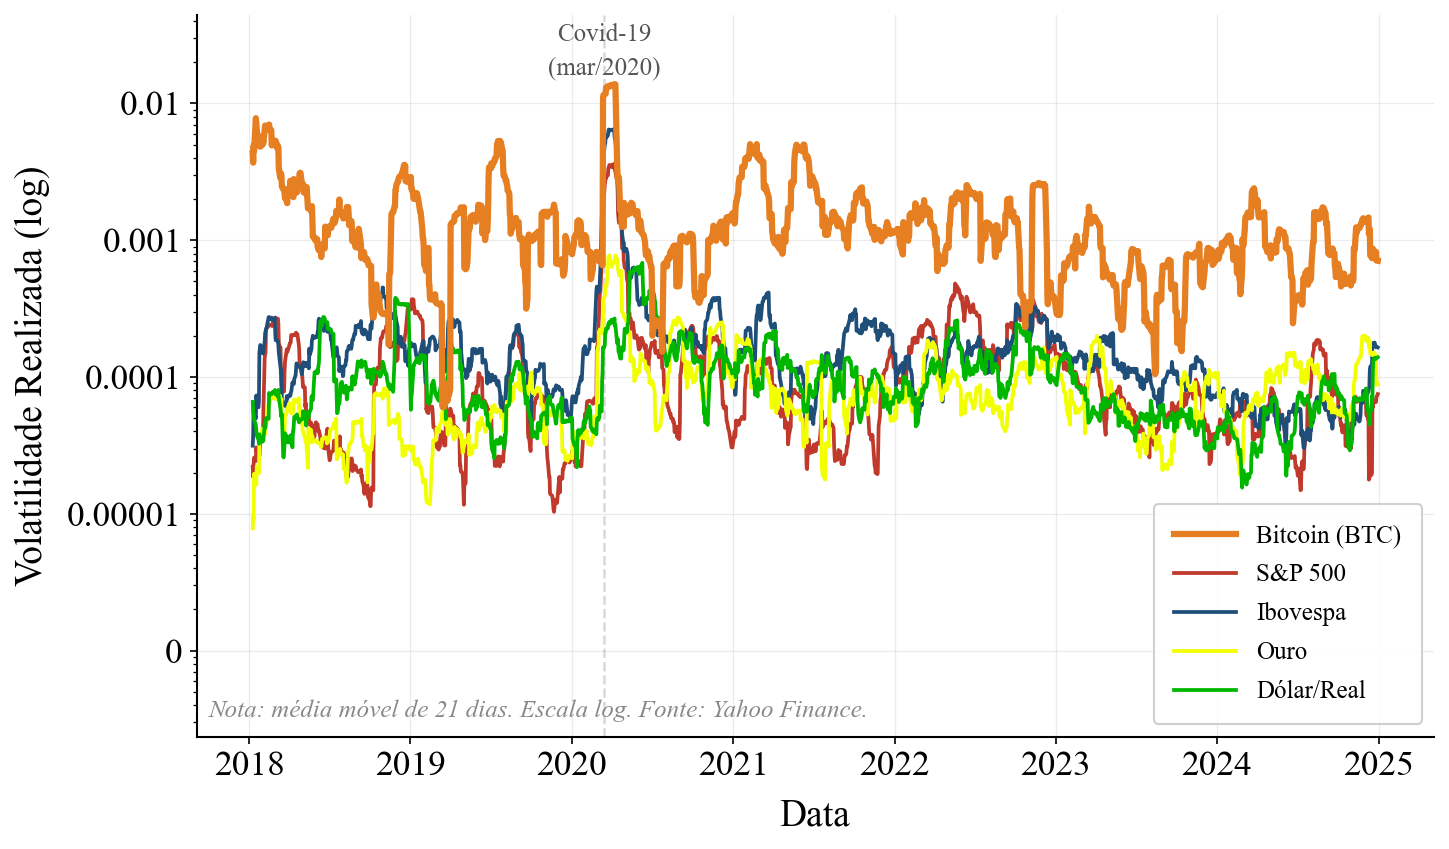

In [47]:
import matplotlib.ticker as mticker

rv_plot = rv_intersecao.copy()
SMOOTH = 21

# ── Piso global ───────────────────────────────────────────────────────────────
all_values = rv_plot.values.flatten()
all_values = all_values[np.isfinite(all_values) & (all_values > 0)]
YMIN = np.percentile(all_values, 5)
YMAX = np.percentile(all_values, 99.5)
rv_plot = rv_plot.clip(lower=YMIN)

# ── Configuração para slides ──────────────────────────────────────────────────
plt.rcParams.update({
    "font.family":      "serif",
    "font.serif":       ["Times New Roman", "DejaVu Serif"],
    "font.size":        18,
    "axes.titlesize":   20,
    "axes.labelsize":   18,
    "xtick.labelsize":  17,
    "ytick.labelsize":  17,
    "legend.fontsize":  17,
    "axes.linewidth":   1.0,
    "grid.alpha":       0.25,
    "grid.linewidth":   0.6,
    "axes.spines.top":  False,
    "axes.spines.right":False,
})

fig1, ax = plt.subplots(figsize=(10, 6))   # mais largo e alto

for ticker, label in LABELS.items():
    if label not in rv_plot.columns:
        continue

    series   = rv_plot[label].dropna()
    is_btc   = ticker == "BTC-USD"
    smoothed = series.rolling(SMOOTH, min_periods=5).mean().dropna()

    ax.plot(smoothed.index, smoothed,
            label=label,
            color=PALETTE[ticker],
            linewidth=3.0 if is_btc else 1.8,   # linhas mais grossas
            alpha=1.0,
            zorder=5 if is_btc else 3)

# ── Escala log ────────────────────────────────────────────────────────────────
ax.set_yscale("log")
ax.set_ylim(YMIN * 0.9, YMAX * 4)

ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{x:.5f}".rstrip("0").rstrip("."))
)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

# ── Anotação Covid ────────────────────────────────────────────────────────────
dt = pd.Timestamp("2020-03-15")
ax.axvline(dt, color="gray", linewidth=1.2, linestyle="--", alpha=0.3, zorder=0)
ax.text(dt, YMAX * 3.5, "Covid-19\n(mar/2020)",
        fontsize=12, color="#555555", ha="center", va="top", linespacing=1.5)

# ── Nota de rodapé ────────────────────────────────────────────────────────────
ax.text(0.01, 0.02,
        f"Nota: média móvel de {SMOOTH} dias. Escala log. Fonte: Yahoo Finance.",
        transform=ax.transAxes,
        fontsize=12, color="#888888", style="italic", va="bottom")

# ── Eixos e legenda ───────────────────────────────────────────────────────────
ax.set_xlabel("Data", labelpad=8)
ax.set_ylabel("Volatilidade Realizada (log)", labelpad=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.legend(loc="best", frameon=True, framealpha=0.92,
          edgecolor="#cccccc", ncol=1, handlelength=2.5,
          borderpad=0.8, labelspacing=0.6, fontsize=12)

plt.tight_layout()
plt.savefig("rv_comparacao.png", dpi=300, bbox_inches="tight")
plt.show()

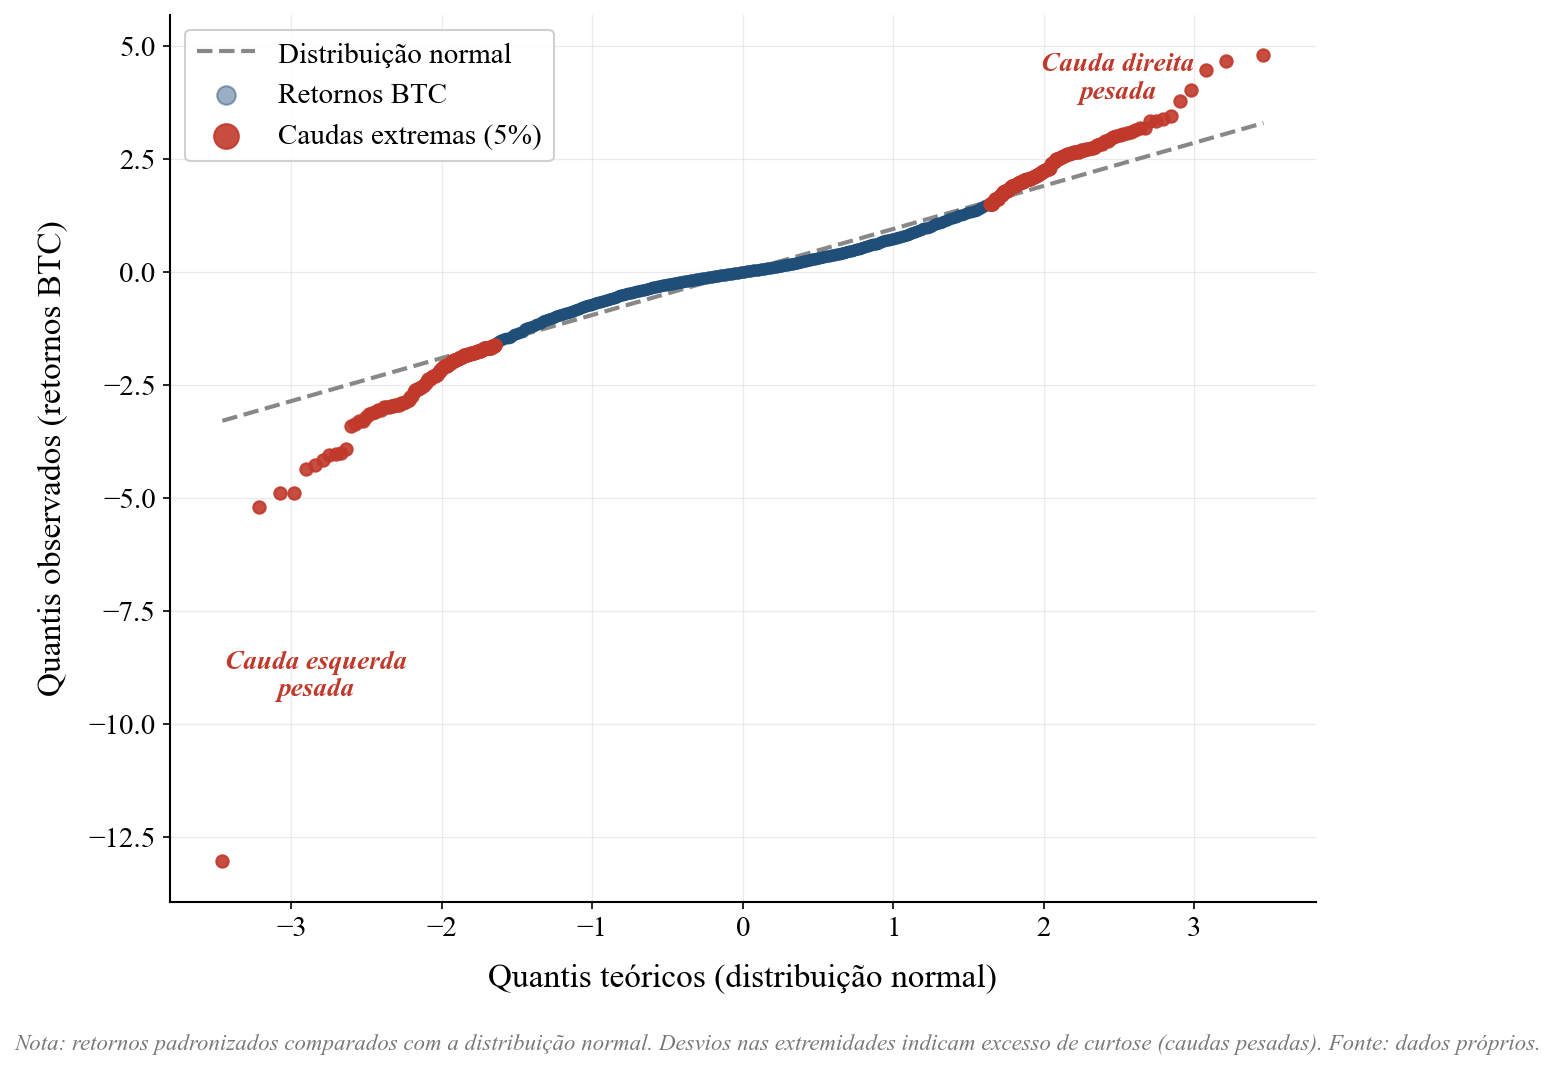

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         16,
    "axes.titlesize":    17,
    "axes.labelsize":    16,
    "xtick.labelsize":   14,
    "ytick.labelsize":   14,
    "legend.fontsize":   14,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.linewidth":    1.0,
    "grid.alpha":        0.25,
    "grid.linewidth":    0.6,
})

# Se tiver o raw do yfinance:
btc_returns = np.log(raw['BTC-USD'] / raw['BTC-USD'].shift(1)).dropna()
btc_returns.index = pd.to_datetime(btc_returns.index)

# Volatilidade realizada — já tem, é o rv_raw['Bitcoin (BTC)']
btc_rv = rv_raw['Bitcoin (BTC)'].dropna()
btc_rv.index = pd.to_datetime(btc_rv.index)

# Alinhar os dois pelo índice
idx_comum = btc_returns.index.intersection(btc_rv.index)
btc_returns = btc_returns.loc[idx_comum]
btc_rv      = btc_rv.loc[idx_comum]

# ── Figura ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

returns_std = (btc_returns - btc_returns.mean()) / btc_returns.std()
(osm, osr), (slope, intercept, _) = stats.probplot(returns_std, dist="norm")

# Linha de referência normal
x_line = np.linspace(min(osm), max(osm), 200)
ax.plot(x_line, slope * x_line + intercept,
        color="#888888", linewidth=2.0, linestyle="--",
        label="Distribuição normal", zorder=2)

# Separar centro e caudas
q_low  = np.percentile(osm, 5)
q_high = np.percentile(osm, 95)
mask_tail   = (np.array(osm) < q_low) | (np.array(osm) > q_high)
mask_center = ~mask_tail

ax.scatter(np.array(osm)[mask_center], np.array(osr)[mask_center],
           color="#1f4e79", s=20, alpha=0.45, zorder=3,
           label="Retornos BTC")
ax.scatter(np.array(osm)[mask_tail], np.array(osr)[mask_tail],
           color="#c0392b", s=35, alpha=0.90, zorder=4,
           label="Caudas extremas (5%)")

# Anotações
ax.annotate("Cauda esquerda\npesada",
            xy=(min(osm) * 0.82, min(osr) * 0.72),
            fontsize=13, color="#c0392b",
            ha="center", style="italic",
            fontweight="bold")
ax.annotate("Cauda direita\npesada",
            xy=(max(osm) * 0.72, max(osr) * 0.80),
            fontsize=13, color="#c0392b",
            ha="center", style="italic",
            fontweight="bold")

ax.set_xlabel("Quantis teóricos (distribuição normal)", labelpad=10)
ax.set_ylabel("Quantis observados (retornos BTC)", labelpad=10)
ax.legend(frameon=True, framealpha=0.92, edgecolor="#cccccc",
          loc="upper left", markerscale=2.0)
ax.grid(True)

fig.text(0.01, -0.02,
         "Nota: retornos padronizados comparados com a distribuição normal. "
         "Desvios nas extremidades indicam excesso de curtose (caudas pesadas). "
         "Fonte: dados próprios.",
         fontsize=11, color="#777777", style="italic")

plt.tight_layout()
plt.savefig("fig_qqplot.png", dpi=300, bbox_inches="tight")
plt.show()